# Unified Control: Mathematical Validation


This notebook provides more rigorous mathematical validation of the unified control framework:

1. Symbolic linearisation of a PCT-controlled plant
2. Symbolic linearisation of an Active Inference-controlled plant
3. Parameter sweeps and eigenvalue spectra


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import unified_control as uc

## 1. Symbolic linearisation: PCT + linear plant

In [2]:
# Define symbols
x, r, k_p, a, b = sp.symbols('x r k_p a b')

# Plant: x' = -a x + b u
# PCT: u = k_p (r - x)
u = k_p * (r - x)
x_dot = -a * x + b * u

# Linearisation around equilibrium x = r
x0 = r
x_dot_linear = sp.simplify(sp.diff(x_dot, x).subs(x, x0) * (x - x0))

A_cl = sp.diff(x_dot, x).subs({x: x0})
sp.simplify(A_cl)


-a - b*k_p

Interpretation: the linearised closed-loop eigenvalue is $A_{\text{cl}} = -a - b k_p$. Stability requires $A_{\text{cl}} < 0$. This matches classical control intuition.

## 2. Symbolic linearisation: Active Inference + linear plant (1D)

In [3]:

# Active inference simplified dynamics (1D):
# mu' = -eta_mu * dF/dmu, a' = -eta_a * dF/da
mu, o, C_sym, P_s, P_o, eta_mu, eta_a, B_a_sym, r_o = sp.symbols(
    'mu o C_sym P_s P_o eta_mu eta_a B_a_sym r_o'
)

# prediction error
pe = o - C_sym * mu
# prior term: P_s * mu
g_mu_prior = P_s * mu
# likelihood term: - C^T P_o (o - C mu) = - C P_o pe
g_mu_like = - C_sym * P_o * pe
# preference term: treat as prior on o: P_o (o - r_o)
g_mu_pref = - C_sym * P_o * (o - r_o)
g_mu = g_mu_prior + g_mu_like + g_mu_pref

# gradient wrt o
g_o = P_o * pe + P_o * (o - r_o)
# gradient wrt a: B_a^T g_o (1D so transpose ignored)
g_a = B_a_sym * g_o

mu_dot = -eta_mu * g_mu
a_dot = -eta_a * g_a

mu_dot_simplified = sp.simplify(mu_dot)
a_dot_simplified = sp.simplify(a_dot)

mu_dot_simplified, a_dot_simplified


(eta_mu*(C_sym*P_o*(o - r_o) - C_sym*P_o*(C_sym*mu - o) - P_s*mu),
 B_a_sym*P_o*eta_a*(C_sym*mu - 2*o + r_o))

These expressions can be evaluated at equilibrium conditions $o = r_o$, $mu = s^\ast$ to obtain a Jacobian for $(\mu, a)$ and to analyse stability analytically or numerically.

## 3. Numerical eigenvalue sweeps

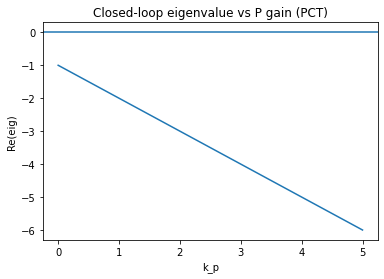

In [4]:

# Build numerical closed-loop matrices for PCT and compare eigenvalues

def pct_closed_loop_matrix(a, b, k_p):
    A = np.array([[-a]])
    B = np.array([[b]])
    C = np.array([[1.0]])
    K = np.array([[k_p]])
    A_cl = A - B @ K @ C
    return A_cl

a_val = 1.0
b_val = 1.0
k_vals = np.linspace(0.0, 5.0, 100)
eig_vals = []

for k in k_vals:
    A_cl = pct_closed_loop_matrix(a_val, b_val, k)
    eig = uc.closed_loop_eigenvalues(A_cl)
    if eig is None:
        eig_vals.append(A_cl[0, 0])
    else:
        eig_vals.append(eig[0].real)

eig_vals = np.array(eig_vals)

plt.figure()
plt.plot(k_vals, eig_vals)
plt.axhline(0.0)
plt.xlabel('k_p')
plt.ylabel('Re(eig)')
plt.title('Closed-loop eigenvalue vs P gain (PCT)')
plt.show()
